# Logistic Regression Credit Default Modeling (UCI Dataset)

## Objective
This notebook develops and evaluates a Logistic Regression benchmark to predict `default payment next month` using the same processed dataset, feature engineering, and held-out test definition used in the LightGBM workflow for fair model comparison.

## 1) Imports and Setup

In [2]:
# Imports and setup
import os
import random
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    roc_curve,
 )
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 140)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid', context='notebook')

## 2) Load Processed Data
We load the same processed dataset used in the tree-based notebook and enforce the same target definition.

In [3]:
# Load processed data
DATA_PATH = 'data/credit_data.csv'
TEST_PATH = 'data/credit_data_test.csv'
TARGET = 'default payment next month'

os.makedirs('Models', exist_ok=True)
os.makedirs('data', exist_ok=True)

df_lr = pd.read_csv(DATA_PATH)
if TARGET not in df_lr.columns:
    raise ValueError(f"Target column '{TARGET}' not found in dataset.")
if 'ID' in df_lr.columns:
    df_lr = df_lr.drop(columns=['ID'])

print(f'Loaded full processed data shape: {df_lr.shape}')
display(df_lr.head(3))

Loaded full processed data shape: (29965, 24)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0


## 3) Feature Engineering
To keep model-family comparison fair, we reuse the same engineered variables used in the LightGBM notebook.

In [4]:
# Feature engineering (same as LightGBM notebook)
def apply_lgbm_feature_engineering(df):
    df = df.copy()

    # 1) Month-to-month bill changes
    for i in range(1, 6):
        df[f'BILL_DIFF_{i}'] = df[f'BILL_AMT{i}'] - df[f'BILL_AMT{i+1}']

    # 2) Aggregate monthly behavior
    bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
    pay_status_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
    pay_amt_cols = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

    df['MEAN_BILL'] = df[bill_cols].mean(axis=1)
    df['MAX_PAY_STATUS'] = df[pay_status_cols].max(axis=1)
    df['SUM_PAY_AMT'] = df[pay_amt_cols].sum(axis=1)

    # 3) Recent payment-to-bill ratio
    df['PAY_RATIO_1'] = df['PAY_AMT1'] / (df['BILL_AMT2'].abs() + 1)

    return df

df_lr = apply_lgbm_feature_engineering(df_lr)
print(f'Feature-engineered full data shape: {df_lr.shape}')

Feature-engineered full data shape: (29965, 33)


## 4) Train/Test Split Logic
The held-out test set is shared with the LightGBM workflow so that test-set comparisons are fair and methodologically consistent.

In [5]:
# Shared hold-out split reconstruction
df_test_holdout = pd.read_csv(TEST_PATH)
if TARGET not in df_test_holdout.columns:
    raise ValueError(f"Target column '{TARGET}' not found in held-out test file.")
if 'ID' in df_test_holdout.columns:
    df_test_holdout = df_test_holdout.drop(columns=['ID'])

required_engineered = [
    'BILL_DIFF_1', 'BILL_DIFF_2', 'BILL_DIFF_3', 'BILL_DIFF_4', 'BILL_DIFF_5',
    'MEAN_BILL', 'MAX_PAY_STATUS', 'SUM_PAY_AMT', 'PAY_RATIO_1',
]
if any(col not in df_test_holdout.columns for col in required_engineered):
    df_test_holdout = apply_lgbm_feature_engineering(df_test_holdout)

shared_cols = [c for c in df_lr.columns if c in df_test_holdout.columns]
df_lr = df_lr[shared_cols]
df_test_holdout = df_test_holdout[shared_cols]

# try to recover exact rows from saved held-out file
df_lr_match = df_lr.copy()
df_test_match = df_test_holdout.copy()
num_cols = df_lr_match.select_dtypes(include=[np.number]).columns
df_lr_match[num_cols] = df_lr_match[num_cols].round(10)
df_test_match[num_cols] = df_test_match[num_cols].round(10)

full_hash = pd.util.hash_pandas_object(df_lr_match, index=False)
test_hash = pd.util.hash_pandas_object(df_test_match, index=False)
test_hash_counts = test_hash.value_counts().to_dict()

mask_test = np.zeros(len(df_lr), dtype=bool)
for idx, h in enumerate(full_hash):
    count = test_hash_counts.get(h, 0)
    if count > 0:
        mask_test[idx] = True
        test_hash_counts[h] = count - 1

if any(v != 0 for v in test_hash_counts.values()):
    # fallback to same LightGBM split logic
    X_full = df_lr.drop(columns=[TARGET])
    y_full = df_lr[TARGET]
    X_train_full, X_test_split, y_train_full, y_test_split = train_test_split(
        X_full,
        y_full,
        test_size=0.20,
        random_state=SEED,
        stratify=y_full,
    )
    df_train_holdout = pd.concat([X_train_full, y_train_full], axis=1).reset_index(drop=True)
    df_test = pd.concat([X_test_split, y_test_split], axis=1).reset_index(drop=True)
    split_note = 'Row matching fallback used: train_test_split with same LightGBM settings.'
else:
    df_train_holdout = df_lr.loc[~mask_test].reset_index(drop=True)
    df_test = df_lr.loc[mask_test].reset_index(drop=True)
    split_note = 'Exact held-out rows recovered from saved LightGBM test file.'

def prop(series):
    return series.value_counts(normalize=True).sort_index().round(4)

print(split_note)
print(f'Full data shape: {df_lr.shape}')
print(f'Train shape: {df_train_holdout.shape}')
print(f'Test shape: {df_test.shape}')
print('\nTarget proportions (full):')
print(prop(df_lr[TARGET]))
print('\nTarget proportions (train):')
print(prop(df_train_holdout[TARGET]))
print('\nTarget proportions (test):')
print(prop(df_test[TARGET]))

Row matching fallback used: train_test_split with same LightGBM settings.
Full data shape: (29965, 33)
Train shape: (23972, 33)
Test shape: (5993, 33)

Target proportions (full):
default payment next month
0    0.7787
1    0.2213
Name: proportion, dtype: float64

Target proportions (train):
default payment next month
0    0.7787
1    0.2213
Name: proportion, dtype: float64

Target proportions (test):
default payment next month
0    0.7787
1    0.2213
Name: proportion, dtype: float64


## 5) Preprocessing and Feature Handling
`SEX`, `EDUCATION`, and `MARRIAGE` are treated as categorical-coded variables. We use one-hot encoding and column alignment so train/test matrices are consistent.

In [6]:
# One-hot encoding and alignment
cat_cols = ['SEX', 'EDUCATION', 'MARRIAGE']

y_train = df_train_holdout[TARGET]
y_test = df_test[TARGET]

X_train_raw = df_train_holdout.drop(columns=[TARGET])
X_test_raw = df_test.drop(columns=[TARGET])

X_train = pd.get_dummies(X_train_raw, columns=cat_cols, drop_first=True)
X_test = pd.get_dummies(X_test_raw, columns=cat_cols, drop_first=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

feature_columns = X_train.columns.tolist()

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')

X_train shape: (23972, 39)
X_test shape: (5993, 39)


## 6) Why Logistic Regression is Useful Here
Logistic Regression is a transparent baseline for binary default prediction. It is computationally efficient, interpretable through coefficients, and useful as a benchmark against more flexible nonlinear models.

## 7) Why Scaling is Needed
Logistic Regression optimization is scale-sensitive. Standardization improves solver stability and comparability across predictors. To avoid leakage, scaling is fit only within training folds via a pipeline during cross-validation.

## 8) Why Calibration is Considered
Calibration focuses on probability quality (how well predicted probabilities reflect observed frequencies), while AUC focuses on ranking quality. In credit-risk settings, well-calibrated probabilities can improve risk-based decision thresholds and expected-loss estimation. Isotonic calibration is used here as a flexible non-parametric approach; it may improve probability reliability without necessarily improving AUC.

## 9) Baseline Logistic Regression Model
We evaluate a leakage-safe baseline using 5-fold stratified CV on training data only, with AUC as the primary metric.

In [7]:
# Baseline leakage-safe CV and training
baseline_logreg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED)
baseline_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('logreg', baseline_logreg),
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
baseline_cv_auc = cross_val_score(baseline_pipeline, X_train, y_train, cv=skf, scoring='roc_auc')
baseline_cv_auc_mean = float(np.mean(baseline_cv_auc))
baseline_cv_auc_std = float(np.std(baseline_cv_auc))

baseline_pipeline_fitted = baseline_pipeline.fit(X_train, y_train)
baseline_test_pred_proba_uncal = baseline_pipeline_fitted.predict_proba(X_test)[:, 1]
baseline_test_auc_uncal = roc_auc_score(y_test, baseline_test_pred_proba_uncal)

print(f'Baseline CV AUC mean: {baseline_cv_auc_mean:.4f}')
print(f'Baseline CV AUC std:  {baseline_cv_auc_std:.4f}')
print(f'Baseline held-out test AUC (uncalibrated): {baseline_test_auc_uncal:.4f}')

Baseline CV AUC mean: 0.7413
Baseline CV AUC std:  0.0086
Baseline held-out test AUC (uncalibrated): 0.7353


## 10) Baseline Cross-Validation Results

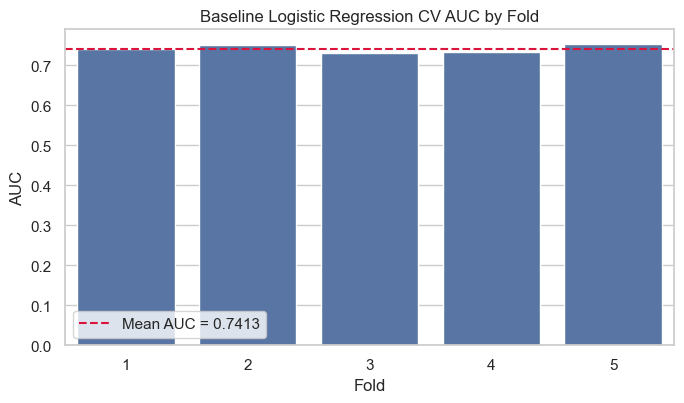

Interpretation: cross-validation indicates modest discrimination; nonlinear models may capture additional structure.


In [8]:
# Baseline CV fold plot and concise interpretation
fold_df = pd.DataFrame({'Fold': np.arange(1, len(baseline_cv_auc) + 1), 'AUC': baseline_cv_auc})

plt.figure(figsize=(7, 4.2))
sns.barplot(data=fold_df, x='Fold', y='AUC', color='#4C72B0')
plt.axhline(baseline_cv_auc_mean, color='crimson', linestyle='--', label=f'Mean AUC = {baseline_cv_auc_mean:.4f}')
plt.title('Baseline Logistic Regression CV AUC by Fold')
plt.ylabel('AUC')
plt.legend()
plt.tight_layout()
plt.show()

if baseline_cv_auc_mean >= 0.75:
    print('Interpretation: cross-validation indicates moderate-to-strong discriminative performance for a linear benchmark.')
else:
    print('Interpretation: cross-validation indicates modest discrimination; nonlinear models may capture additional structure.')

## 11) Baseline Held-Out Test Evaluation
Calibration is applied after baseline training to improve probability reliability on unseen data.

In [9]:
# Baseline isotonic calibration and held-out test evaluation
baseline_calibrated = CalibratedClassifierCV(baseline_pipeline, method='isotonic', cv=5)
baseline_calibrated.fit(X_train, y_train)

baseline_test_pred_proba = baseline_calibrated.predict_proba(X_test)[:, 1]
baseline_test_pred_label = (baseline_test_pred_proba >= 0.5).astype(int)
baseline_test_auc = roc_auc_score(y_test, baseline_test_pred_proba)

print(classification_report(y_test, baseline_test_pred_label))
print(f'Baseline held-out test AUC (calibrated): {baseline_test_auc:.4f}')
print(f'Calibration AUC delta (calibrated - uncalibrated): {baseline_test_auc - baseline_test_auc_uncal:+.4f}')

if baseline_test_auc >= 0.75:
    print('Interpretation: baseline logistic regression shows moderate-to-strong ranking ability on held-out data.')
else:
    print('Interpretation: baseline logistic regression shows modest ranking ability on held-out data.')
print('Note: calibration primarily targets probability quality, so AUC may change only slightly.')

              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4667
           1       0.62      0.37      0.47      1326

    accuracy                           0.81      5993
   macro avg       0.73      0.65      0.68      5993
weighted avg       0.79      0.81      0.79      5993

Baseline held-out test AUC (calibrated): 0.7361
Calibration AUC delta (calibrated - uncalibrated): +0.0008
Interpretation: baseline logistic regression shows modest ranking ability on held-out data.
Note: calibration primarily targets probability quality, so AUC may change only slightly.


The baseline logistic regression model achieved moderate performance on the held-out test set, indicating that a linear model can capture some meaningful default-risk structure in the data. However, its performance is lower than that of the tree-based models, which suggests that the relationship between predictors and default risk may include nonlinear effects or interactions that logistic regression cannot fully capture.

## 12) Hyperparameter Tuning
A compact grid search is run on training data only. We tune regularization strength (`C`) and `class_weight` using 5-fold stratified CV and AUC.

In [10]:
# Modest hyperparameter tuning (training data only)
C_values = [0.1, 0.5, 1.0, 2.0, 5.0]
class_weight_options = ['balanced', None]

search_results = []
combo_id = 0

for c in C_values:
    for cw in class_weight_options:
        combo_id += 1
        trial_logreg = LogisticRegression(
            C=c,
            class_weight=cw,
            max_iter=1000,
            random_state=SEED,
        )
        trial_pipeline = Pipeline(steps=[
            ('scaler', StandardScaler()),
            ('logreg', trial_logreg),
        ])

        trial_cv_auc = cross_val_score(trial_pipeline, X_train, y_train, cv=skf, scoring='roc_auc')
        search_results.append({
            'combo': f'C{combo_id:02d}',
            'C': c,
            'class_weight': str(cw),
            'mean_cv_auc': float(np.mean(trial_cv_auc)),
            'std_cv_auc': float(np.std(trial_cv_auc)),
        })

results_df = pd.DataFrame(search_results).sort_values(
    by=['mean_cv_auc', 'std_cv_auc'], ascending=[False, True]
).reset_index(drop=True)

display(results_df)

,combo,C,class_weight,mean_cv_auc,std_cv_auc
0,C03,0.5,balanced,0.741299,0.008658
1,C05,1.0,balanced,0.741289,0.008632
2,C07,2.0,balanced,0.741266,0.008595
3,C09,5.0,balanced,0.741256,0.008576
4,C01,0.1,balanced,0.741246,0.008731
5,C06,1.0,None,0.741023,0.008908
6,C04,0.5,None,0.741018,0.008990
7,C08,2.0,None,0.740992,0.008854
8,C10,5.0,None,0.740987,0.008819
9,C02,0.1,None,0.740969,0.009055


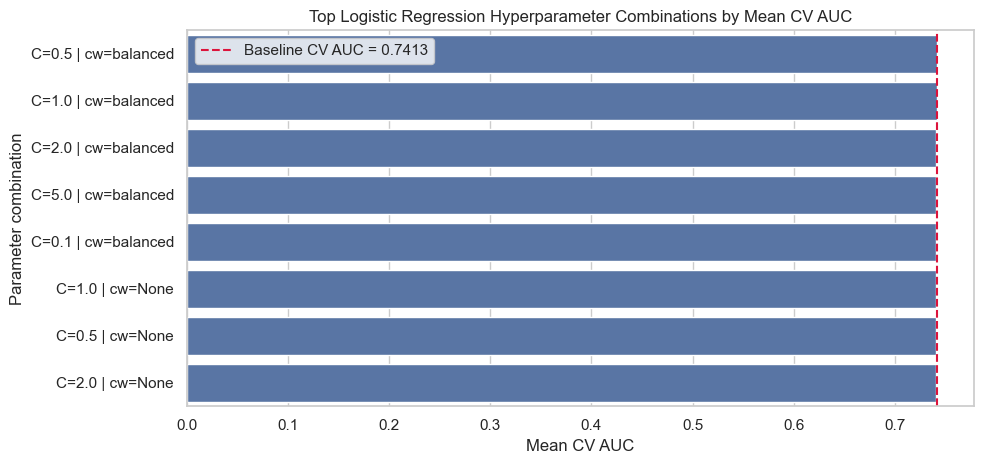

In [11]:
# Tuning results plot
plot_df = results_df.head(8).copy()
plot_df['label'] = 'C=' + plot_df['C'].astype(str) + ' | cw=' + plot_df['class_weight']

plt.figure(figsize=(10, 4.8))
sns.barplot(data=plot_df, x='mean_cv_auc', y='label', color='#4C72B0')
plt.axvline(baseline_cv_auc_mean, color='crimson', linestyle='--', label=f'Baseline CV AUC = {baseline_cv_auc_mean:.4f}')
plt.title('Top Logistic Regression Hyperparameter Combinations by Mean CV AUC')
plt.xlabel('Mean CV AUC')
plt.ylabel('Parameter combination')
plt.legend()
plt.tight_layout()
plt.show()

## 13) Tuning Results
The best configuration is selected by mean CV AUC (with lower variability preferred when scores are close).

In [12]:
# Final tuned model training and held-out evaluation
best_row = results_df.iloc[0]
best_tuned_params = {
    'C': float(best_row['C']),
    'class_weight': None if best_row['class_weight'] == 'None' else best_row['class_weight'],
    'max_iter': 1000,
    'random_state': SEED,
}

tuned_logreg = LogisticRegression(**best_tuned_params)
tuned_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('logreg', tuned_logreg),
])

tuned_pipeline_fitted = tuned_pipeline.fit(X_train, y_train)
tuned_test_pred_proba_uncal = tuned_pipeline_fitted.predict_proba(X_test)[:, 1]
tuned_test_auc_uncal = roc_auc_score(y_test, tuned_test_pred_proba_uncal)

tuned_calibrated = CalibratedClassifierCV(tuned_pipeline, method='isotonic', cv=5)
tuned_calibrated.fit(X_train, y_train)
tuned_test_pred_proba = tuned_calibrated.predict_proba(X_test)[:, 1]
tuned_test_pred_label = (tuned_test_pred_proba >= 0.5).astype(int)
tuned_test_auc = roc_auc_score(y_test, tuned_test_pred_proba)

tuned_cv_auc_mean = float(best_row['mean_cv_auc'])
tuned_cv_auc_std = float(best_row['std_cv_auc'])

print('Best tuned parameters:')
print(best_tuned_params)
print(f'Tuned CV AUC mean: {tuned_cv_auc_mean:.4f}')
print(f'Tuned CV AUC std:  {tuned_cv_auc_std:.4f}')
print(f'Tuned held-out test AUC (uncalibrated): {tuned_test_auc_uncal:.4f}')
print(f'Tuned held-out test AUC (calibrated):   {tuned_test_auc:.4f}')

Best tuned parameters:
{'C': 0.5, 'class_weight': 'balanced', 'max_iter': 1000, 'random_state': 42}
Tuned CV AUC mean: 0.7413
Tuned CV AUC std:  0.0087
Tuned held-out test AUC (uncalibrated): 0.7353
Tuned held-out test AUC (calibrated):   0.7364


Hyperparameter tuning produced only a small improvement in performance, indicating that the baseline logistic regression configuration was already a reasonable starting point. This suggests that, for this dataset, the main limitation of logistic regression is likely the model’s linear structure rather than poor parameter choice.

## 14) Final Selected Logistic Regression Model
We compare baseline and tuned variants on the same held-out test set and retain the better out-of-sample model.

In [13]:
# Baseline vs tuned comparison and selection
comparison_df = pd.DataFrame([
    {'metric': 'Baseline CV AUC (mean)', 'value': baseline_cv_auc_mean},
    {'metric': 'Baseline test AUC (calibrated)', 'value': baseline_test_auc},
    {'metric': 'Tuned CV AUC (mean)', 'value': tuned_cv_auc_mean},
    {'metric': 'Tuned test AUC (calibrated)', 'value': tuned_test_auc},
    {'metric': 'CV AUC gain (tuned - baseline)', 'value': tuned_cv_auc_mean - baseline_cv_auc_mean},
    {'metric': 'Test AUC gain (tuned - baseline)', 'value': tuned_test_auc - baseline_test_auc},
])
display(comparison_df.round(4))

if tuned_test_auc > baseline_test_auc:
    selected_model_name = 'tuned'
    selected_model = tuned_calibrated
    selected_pipeline_for_coef = tuned_pipeline_fitted
    selected_test_pred_proba = tuned_test_pred_proba
    selected_test_pred_label = tuned_test_pred_label
    selected_test_auc = tuned_test_auc
    selection_note = 'Tuned logistic model retained as final benchmark based on higher held-out test AUC.'
else:
    selected_model_name = 'baseline'
    selected_model = baseline_calibrated
    selected_pipeline_for_coef = baseline_pipeline_fitted
    selected_test_pred_proba = baseline_test_pred_proba
    selected_test_pred_label = baseline_test_pred_label
    selected_test_auc = baseline_test_auc
    selection_note = 'Baseline logistic model retained as final benchmark because tuning did not improve held-out test AUC.'

print(selection_note)

,metric,value
0,Baseline CV AUC (mean),0.7413
1,Baseline test AUC (calibrated),0.7361
2,Tuned CV AUC (mean),0.7413
3,Tuned test AUC (calibrated),0.7364
4,CV AUC gain (tuned - baseline),0.0000
5,Test AUC gain (tuned - baseline),0.0003


Tuned logistic model retained as final benchmark based on higher held-out test AUC.


Although the performance gain was modest, the tuned logistic regression model slightly outperformed the baseline on the held-out test set and was therefore retained as the final logistic benchmark. The improvement is small, so the tuned model should be viewed as a refined linear baseline rather than a substantially different model.

## 15) Model Diagnostics
Diagnostics summarize discrimination, threshold behavior, class separation in predicted probabilities, and coefficient directionality for the final selected model.

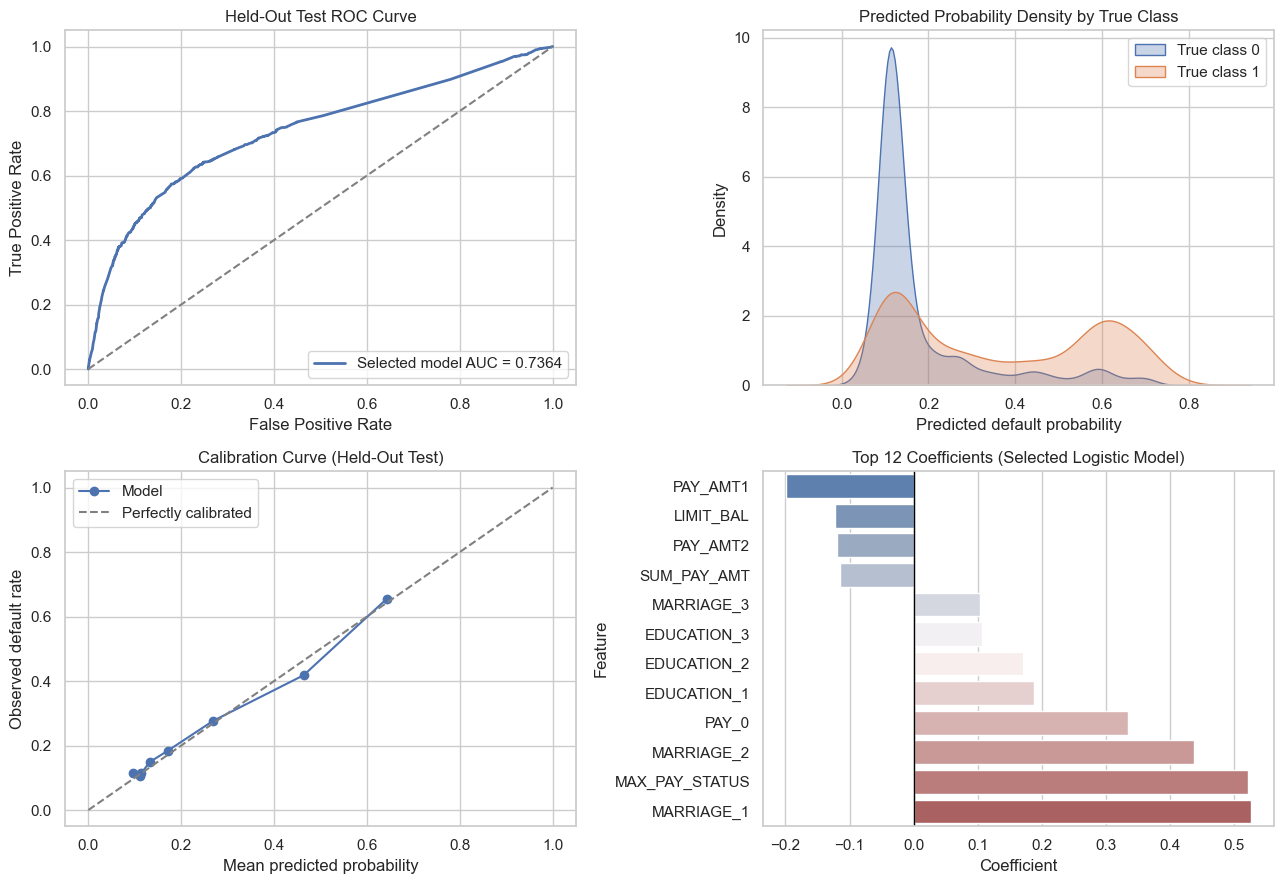

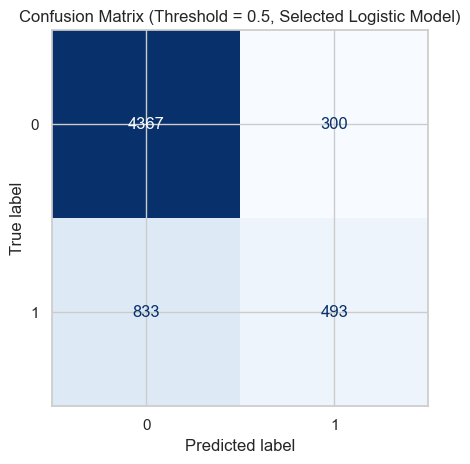

,feature,top_positive_coef,abs_coefficient
36,MARRIAGE_1,0.525633,0.525633
26,MAX_PAY_STATUS,0.521187,0.521187
37,MARRIAGE_2,0.437403,0.437403
2,PAY_0,0.333996,0.333996
30,EDUCATION_1,0.187936,0.187936
31,EDUCATION_2,0.169816,0.169816
32,EDUCATION_3,0.106314,0.106314
38,MARRIAGE_3,0.103755,0.103755
3,PAY_2,0.069115,0.069115
1,AGE,0.051745,0.051745


,feature,top_negative_coef,abs_coefficient
14,PAY_AMT1,-0.198361,0.198361
0,LIMIT_BAL,-0.122010,0.122010
15,PAY_AMT2,-0.119933,0.119933
27,SUM_PAY_AMT,-0.114168,0.114168
20,BILL_DIFF_1,-0.096057,0.096057
7,PAY_6,-0.094385,0.094385
34,EDUCATION_5,-0.072966,0.072966
17,PAY_AMT4,-0.054508,0.054508
29,SEX_2,-0.048560,0.048560
8,BILL_AMT1,-0.033648,0.033648


Interpretation summary:
- ROC indicates modest discriminative ability on held-out data.
- Probability densities show partial class separation, not complete separation.
- Confusion matrix at threshold 0.5 highlights residual class-imbalance trade-offs.
- Coefficients indicate directional effects on predicted default risk, controlling for other variables.


In [14]:
# ROC, probability density, confusion matrix, calibration curve, and coefficients
fpr_sel, tpr_sel, _ = roc_curve(y_test, selected_test_pred_proba)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# ROC
axes[0, 0].plot(fpr_sel, tpr_sel, color='#4C72B0', linewidth=2, label=f'Selected model AUC = {selected_test_auc:.4f}')
axes[0, 0].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[0, 0].set_title('Held-Out Test ROC Curve')
axes[0, 0].set_xlabel('False Positive Rate')
axes[0, 0].set_ylabel('True Positive Rate')
axes[0, 0].legend(loc='lower right')

# Probability density
sns.kdeplot(x=selected_test_pred_proba[y_test.values == 0], fill=True, alpha=0.3, label='True class 0', ax=axes[0, 1], color='#4C72B0')
sns.kdeplot(x=selected_test_pred_proba[y_test.values == 1], fill=True, alpha=0.3, label='True class 1', ax=axes[0, 1], color='#DD8452')
axes[0, 1].set_title('Predicted Probability Density by True Class')
axes[0, 1].set_xlabel('Predicted default probability')
axes[0, 1].set_ylabel('Density')
axes[0, 1].legend()

# Calibration curve
prob_true, prob_pred = calibration_curve(y_test, selected_test_pred_proba, n_bins=10, strategy='quantile')
axes[1, 0].plot(prob_pred, prob_true, marker='o', color='#4C72B0', label='Model')
axes[1, 0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly calibrated')
axes[1, 0].set_title('Calibration Curve (Held-Out Test)')
axes[1, 0].set_xlabel('Mean predicted probability')
axes[1, 0].set_ylabel('Observed default rate')
axes[1, 0].legend()

# Coefficient magnitude (top 12)
coef_values = selected_pipeline_for_coef.named_steps['logreg'].coef_[0]
coef_df = pd.DataFrame({'feature': feature_columns, 'coefficient': coef_values})
coef_df['abs_coefficient'] = coef_df['coefficient'].abs()
coef_top = coef_df.sort_values('abs_coefficient', ascending=False).head(12).sort_values('coefficient')

sns.barplot(data=coef_top, y='feature', x='coefficient', ax=axes[1, 1], palette='vlag')
axes[1, 1].axvline(0, color='black', linewidth=1)
axes[1, 1].set_title('Top 12 Coefficients (Selected Logistic Model)')
axes[1, 1].set_xlabel('Coefficient')
axes[1, 1].set_ylabel('Feature')

plt.tight_layout()
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test, selected_test_pred_label, cmap='Blues', colorbar=False)
plt.title('Confusion Matrix (Threshold = 0.5, Selected Logistic Model)')
plt.tight_layout()
plt.show()

display(coef_df.sort_values('coefficient', ascending=False).head(10).rename(columns={'coefficient': 'top_positive_coef'}))
display(coef_df.sort_values('coefficient', ascending=True).head(10).rename(columns={'coefficient': 'top_negative_coef'}))

# concise interpretation based on outputs
print('Interpretation summary:')
if selected_test_auc >= 0.75:
    print('- ROC indicates moderate-to-strong discriminative ability on held-out data.')
else:
    print('- ROC indicates modest discriminative ability on held-out data.')
print('- Probability densities show partial class separation, not complete separation.')
print('- Confusion matrix at threshold 0.5 highlights residual class-imbalance trade-offs.')
print('- Coefficients indicate directional effects on predicted default risk, controlling for other variables.')

The diagnostic results indicate that the final logistic regression model provides moderate discriminatory power on the held-out test set. The ROC curve and predicted probability distributions show that the model captures meaningful differences between defaulters and non-defaulters, but class overlap remains substantial. The confusion matrix suggests that performance at the default 0.5 threshold is constrained by class imbalance, particularly through lower recall for defaulters. The coefficient analysis is directionally consistent with the credit-risk setting, with recent repayment delays increasing predicted default risk and stronger payment behavior decreasing it.

## 16) Artifact Saving
We save logistic-specific artifacts for reproducibility and downstream evaluation, including the final selected model object and exact training feature columns.

In [16]:
# Save final logistic artifacts
FINAL_MODEL_PATH = 'Models/logreg_model.joblib'
FINAL_PIPELINE_PATH = 'Models/logreg_pipeline.joblib'
FEATURE_PATH = 'Models/logreg_feature_columns.pkl'

joblib.dump(selected_model, FINAL_MODEL_PATH)
joblib.dump(selected_pipeline_for_coef, FINAL_PIPELINE_PATH)
joblib.dump(feature_columns, FEATURE_PATH)

print(f'Final calibrated logistic model saved to: {FINAL_MODEL_PATH}')
print(f'Final logistic pipeline saved to: {FINAL_PIPELINE_PATH}')
print(f'Logistic feature columns saved to: {FEATURE_PATH}')
print(f'Selected final variant: {selected_model_name}')

Final calibrated logistic model saved to: Models/logreg_model.joblib
Final logistic pipeline saved to: Models/logreg_pipeline.joblib
Logistic feature columns saved to: Models/logreg_feature_columns.pkl
Selected final variant: tuned


## 17) Final Summary
- The logistic workflow reuses LightGBM feature engineering and held-out split definitions for fair model comparison.
- Cross-validation and tuning are performed only on training data with leakage-safe scaling inside pipelines.
- Calibration is included to improve probability reliability for risk-oriented use cases.
- Final model selection is based on held-out test AUC between baseline and tuned logistic variants.

In [32]:
# Compact final report table
final_report = pd.DataFrame([
    {'metric': 'Baseline CV AUC (mean)', 'value': baseline_cv_auc_mean},
    {'metric': 'Baseline test AUC (calibrated)', 'value': baseline_test_auc},
    {'metric': 'Tuned CV AUC (mean)', 'value': tuned_cv_auc_mean},
    {'metric': 'Tuned test AUC (calibrated)', 'value': tuned_test_auc},
    {'metric': 'Final selected model test AUC', 'value': selected_test_auc},
])
display(final_report.round(4))

print(f'Final selected logistic model: {selected_model_name}')
if selected_model_name == 'tuned':
    print('Interpretation: modest tuning improved held-out performance and was retained.')
else:
    print('Interpretation: tuning gains in CV did not improve held-out performance; baseline was retained.')

,metric,value
0,Baseline CV AUC (mean),0.7413
1,Baseline test AUC (calibrated),0.7361
2,Tuned CV AUC (mean),0.7413
3,Tuned test AUC (calibrated),0.7364
4,Final selected model test AUC,0.7364


Final selected logistic model: tuned
Interpretation: modest tuning improved held-out performance and was retained.


The logistic regression model provided a useful linear benchmark using the same shared data pipeline and held-out test set as the other models. After modest tuning and calibration, the final model achieved a test AUC of approximately 0.736, indicating moderate discriminative ability. While its predictive performance was below that of the tree-based models, it remains valuable because it offers a transparent and interpretable reference point for understanding the direction of key risk factors.